# 01 - EDA y limpieza

**Objetivo de este notebook:** explorar las distribuciones de las variables clave de `accepted` (préstamos otorgados) y `rejected` (solicitudes rechazadas), documentar el mapeo de columnas equivalentes entre ambos datasets, tomar y justificar las decisiones de limpieza, y guardar los datasets limpios en `data/processed/`.

Este es el insumo para la Fase 3 (unión accepted+rejected en el dataset de "demanda") y para los modelos de las Fases 5-7. Las reglas de limpieza en sí viven en `src/preprocessing.py` (código reutilizable, testeado) -- este notebook las ejecuta, explica el *por qué* de negocio de cada decisión, y visualiza el resultado.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import clean_accepted, clean_rejected  # noqa: E402

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"

accepted = pd.read_csv(RAW_DIR / "accepted_sample.csv.gz", low_memory=False)
rejected = pd.read_csv(RAW_DIR / "rejected_sample.csv.gz", low_memory=False)

print(f"accepted: {accepted.shape}")
print(f"rejected: {rejected.shape}")

accepted: (150000, 151)
rejected: (150000, 9)


## 1. `accepted` -- préstamos otorgados

Estas son las variables que van a alimentar tanto el modelo de demanda (Fase 5, combinado con `rejected`) como los modelos de PD/LGD (Fase 7, que usan solo `accepted` porque necesitan el desenlace del préstamo).

In [3]:
key_cols_accepted = [
    "int_rate", "funded_amnt", "fico_range_low", "fico_range_high",
    "grade", "sub_grade", "dti", "term", "loan_status", "emp_length", "purpose",
]
missing_accepted = accepted[key_cols_accepted].isna().mean().sort_values(ascending=False)
print("% de missing en columnas clave:")
print(missing_accepted[missing_accepted > 0])

% de missing en columnas clave:
emp_length         0.064867
dti                0.000827
int_rate           0.000027
fico_range_low     0.000027
funded_amnt        0.000027
grade              0.000027
fico_range_high    0.000027
sub_grade          0.000027
term               0.000027
loan_status        0.000027
purpose            0.000027
dtype: float64


**Hallazgo:** además del ~6.5% de missing en `emp_length` (antigüedad laboral no siempre reportada por el solicitante), hay 4 filas con casi todo NaN. Al inspeccionarlas, su `id` es literalmente el texto `"Total amount funded in policy code 1: ..."` -- son filas de resumen que Lending Club agrega al final del CSV exportado, no préstamos reales. Se descartan en `clean_accepted`.

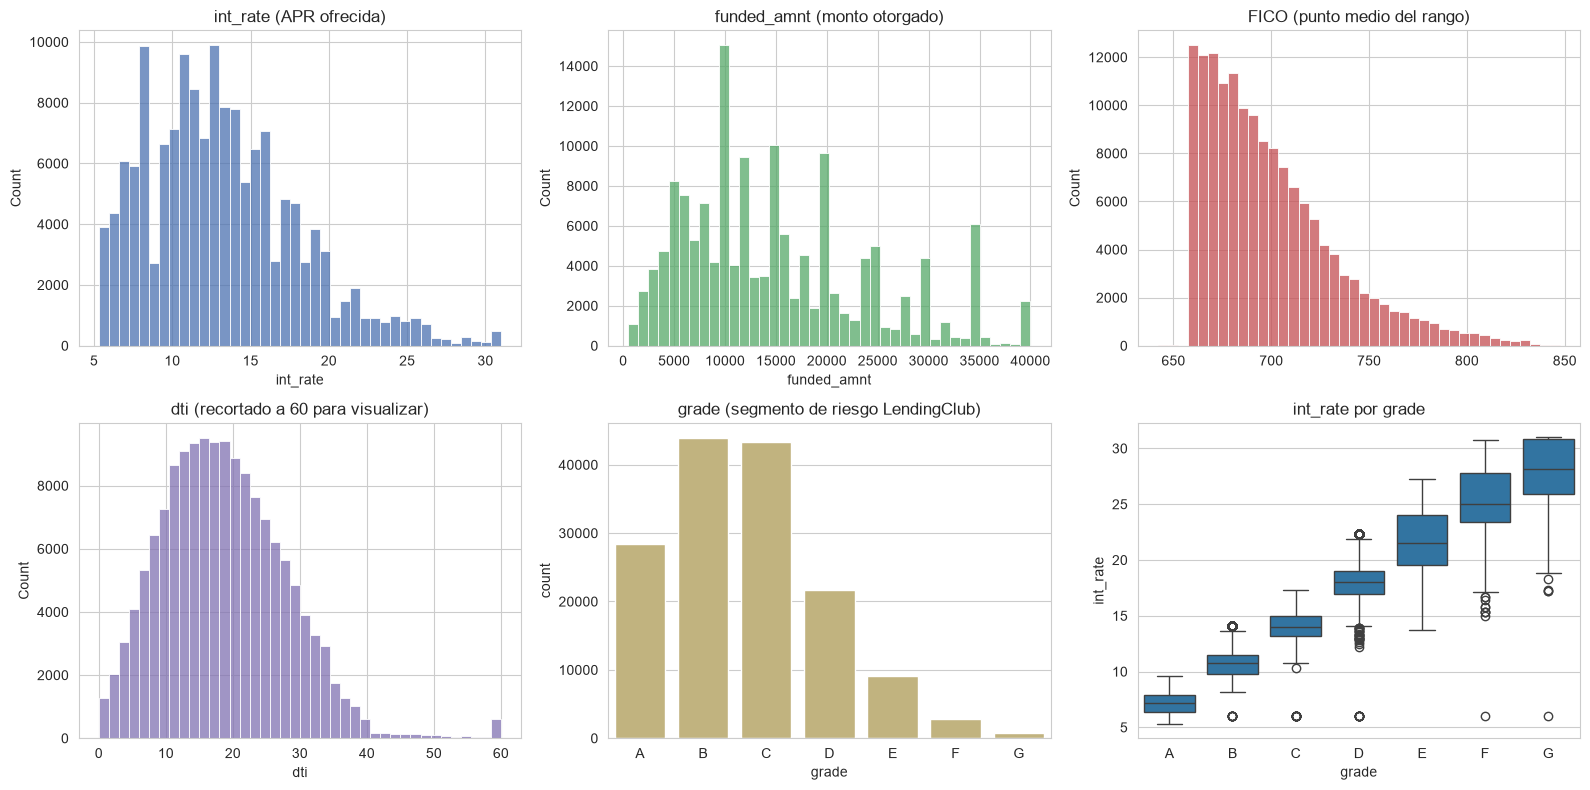

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.histplot(accepted["int_rate"], bins=40, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("int_rate (APR ofrecida)")

sns.histplot(accepted["funded_amnt"], bins=40, ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("funded_amnt (monto otorgado)")

fico_mid = (accepted["fico_range_low"] + accepted["fico_range_high"]) / 2
sns.histplot(fico_mid, bins=40, ax=axes[0, 2], color="#C44E52")
axes[0, 2].set_title("FICO (punto medio del rango)")

sns.histplot(accepted["dti"].clip(upper=60), bins=40, ax=axes[1, 0], color="#8172B2")
axes[1, 0].set_title("dti (recortado a 60 para visualizar)")

order = sorted(accepted["grade"].dropna().unique())
sns.countplot(x="grade", data=accepted, order=order, ax=axes[1, 1], color="#CCB974")
axes[1, 1].set_title("grade (segmento de riesgo LendingClub)")

sns.boxplot(x="grade", y="int_rate", data=accepted, order=order, ax=axes[1, 2])
axes[1, 2].set_title("int_rate por grade")

plt.tight_layout()
plt.show()

**Lectura de negocio:** `int_rate` sube monótonamente con `grade` (A -> G), que es exactamente la restricción de monotonicidad de riesgo que vamos a imponerle al optimizador en la Fase 8 (segmentos más riesgosos deben recibir tasa >= que segmentos menos riesgosos) -- confirma que el pricing histórico de LendingClub ya sigue esa lógica, así que es un buen benchmark para comparar contra las tasas optimizadas en la Fase 10.

`dti` tiene una cola larga de valores extremos (hasta 999) que no son creíbles para un préstamo ya otorgado -- se tratan como outliers en la limpieza (ver más abajo).

## 2. `rejected` -- solicitudes rechazadas

`rejected` trae muchas menos columnas que `accepted` (9 vs. 151). No tiene tasa ofrecida explícita (tiene sentido: a un solicitante rechazado nunca se le llegó a cotizar una tasa) -- por eso, siguiendo el prompt del proyecto, usamos `Risk_Score` como proxy de riesgo del solicitante en el modelo de demanda de la Fase 5.

In [5]:
missing_rejected = rejected.isna().mean().sort_values(ascending=False)
print("% de missing por columna:")
print(missing_rejected)

% de missing por columna:
Risk_Score              0.666287
Employment Length       0.034353
Loan Title              0.000047
Policy Code             0.000027
Amount Requested        0.000000
Debt-To-Income Ratio    0.000000
Application Date        0.000000
State                   0.000000
Zip Code                0.000000
dtype: float64


**Hallazgo importante:** `Risk_Score` falta en **66.6%** de las solicitudes rechazadas de la muestra. Antes de decidir cómo tratarlo, hay que verificar si el missing es aleatorio o está concentrado en el tiempo (si está concentrado, imputar con la media global sesgaría el feature hacia los años donde sí hay dato).

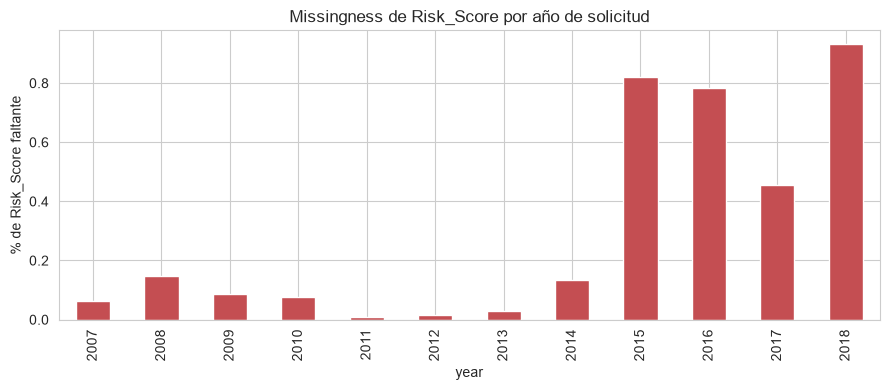

year
2007    0.064516
2008    0.148936
2009    0.085627
2010    0.076142
2011    0.009524
2012    0.014525
2013    0.028853
2014    0.135327
2015    0.819960
2016    0.782058
2017    0.454776
2018    0.931396
Name: Risk_Score, dtype: float64

In [6]:
rejected["year"] = pd.to_datetime(rejected["Application Date"]).dt.year
risk_score_missing_by_year = rejected.groupby("year")["Risk_Score"].apply(lambda s: s.isna().mean())

fig, ax = plt.subplots(figsize=(9, 4))
risk_score_missing_by_year.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("% de Risk_Score faltante")
ax.set_title("Missingness de Risk_Score por año de solicitud")
plt.tight_layout()
plt.show()

risk_score_missing_by_year

**Confirmado: el missing NO es aleatorio.** Se mantiene por debajo del 15% entre 2007 y 2014, y luego se dispara: 45% en 2017 y **93% en 2018**. Esto es una limitación real de la fuente de datos (LendingClub dejó de poblar `Risk_Score` de forma sistemática para la mayoría de rechazos recientes), no un artefacto del muestreo de este proyecto.

**Decisión de limpieza:** no se imputa con la media/mediana global (sesgaría el feature hacia los años pre-2015, sobre-representados entre los registros con dato). En su lugar:
- Se conserva `Risk_Score` con sus NaN.
- Se agrega un flag `risk_score_missing` (booleano).
- El modelo de demanda (Fase 5) podrá usar ambas señales -- el nivel de riesgo cuando está disponible, y el hecho de que falte como señal en sí misma (correlaciona con el año de la solicitud, que a su vez correlaciona con cambios en el proceso de underwriting de LendingClub).

Esta limitación queda documentada también en el README del proyecto.

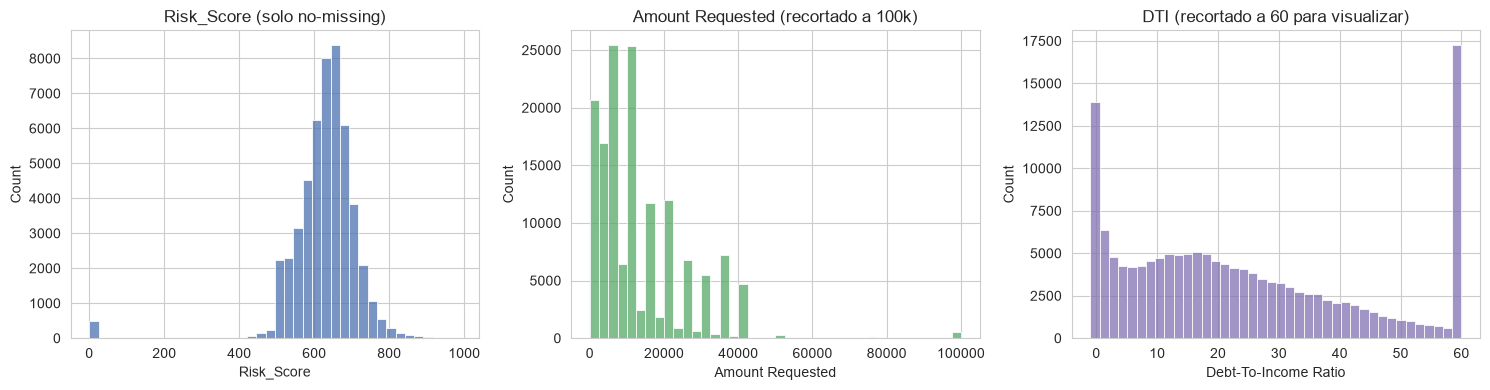

Amount Requested == 0: 7 filas (se descartan)


In [7]:
dti_rejected = rejected["Debt-To-Income Ratio"].astype(str).str.rstrip("%").astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rejected["Risk_Score"].dropna(), bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Risk_Score (solo no-missing)")

sns.histplot(rejected["Amount Requested"].clip(upper=100_000), bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Amount Requested (recortado a 100k)")

sns.histplot(dti_rejected.clip(upper=60), bins=40, ax=axes[2], color="#8172B2")
axes[2].set_title("DTI (recortado a 60 para visualizar)")

plt.tight_layout()
plt.show()

print("Amount Requested == 0:", (rejected["Amount Requested"] == 0).sum(), "filas (se descartan)")

## 3. Mapeo de columnas equivalentes entre `accepted` y `rejected`

Los nombres y formatos difieren, así que antes de la unión de la Fase 3 se necesita este mapeo explícito (implementado en `src/preprocessing.py`):

| Concepto | `accepted` | `rejected` | Nota |
|---|---|---|---|
| Monto | `funded_amnt` | `Amount Requested` | En accepted es el monto *otorgado*; en rejected es el *solicitado* (nunca se otorgó nada) |
| DTI | `dti` (float) | `Debt-To-Income Ratio` (texto con "%") | Se parsea el "%" y se lleva a la misma escala |
| Riesgo | `fico_range_low`/`fico_range_high` -> `fico` (punto medio) | `Risk_Score` | Son escalas *distintas* (FICO ~300-850 vs. Risk_Score con otro rango/origen) -- no se homologan a una sola escala numérica, se dejan como features separadas y se deja que el modelo (Fase 5) aprenda su relación con la variable objetivo cada una en su propio dataset de origen |
| Antigüedad laboral | `emp_length` | `Employment Length` | Mismo formato de texto, mismo mapeo (`EMP_LENGTH_MAP`) |
| Propósito | `purpose` (categórico limpio) | `Loan Title` (texto libre) | Se normaliza `Loan Title` a las mismas 14 categorías de `purpose` vía `map_loan_title_to_purpose` |
| Ubicación | `zip_code` / `addr_state` | `Zip Code` / `State` | Mismo formato (3 dígitos + "xx" enmascarado) |
| Tasa ofrecida | `int_rate` | *(no existe)* | Un rechazo nunca llega a cotización -- limitación estructural del dataset, ver README |
| Fecha | `issue_d` | `Application Date` | Distinta granularidad (mes vs. día) |

**Limitación reconocida (documentada también en el README):** en `rejected` no siempre se distingue si el *cliente* rechazó la oferta o el *banco* rechazó al cliente antes de llegar a ofertar nada -- es un proxy razonable de `F̄_i(r)` (la fracción que acepta, en la notación de Phillips), no una medición perfecta, porque Phillips asume que `D_i` ya pasó underwriting. Se documenta y se sigue adelante porque es la mejor aproximación disponible en un dataset público.

## 4. Aplicar limpieza y guardar en `data/processed/`

Se aplican `clean_accepted` y `clean_rejected` de `src/preprocessing.py` (resumen de las decisiones, ya justificadas arriba y en los docstrings del módulo):

- **accepted:** se descartan las 4 filas de resumen; `term` -> entero; `emp_length` -> años numéricos; `fico` = punto medio de fico_range; `dti` > 100 -> NaN (outlier no creíble).
- **rejected:** se descartan las ~7 filas con `Amount Requested == 0`; DTI parseado de texto a float; `Risk_Score` se conserva con NaN + flag `risk_score_missing`; `Loan Title` normalizado a categorías de `purpose`.

In [8]:
accepted_clean = clean_accepted(accepted)
rejected_clean = clean_rejected(rejected)

print(f"accepted: {accepted.shape} -> {accepted_clean.shape}")
print(f"rejected: {rejected.shape} -> {rejected_clean.shape}")

assert accepted_clean["dti_clean"].max() <= 100
assert rejected_clean["Amount Requested"].min() > 0

accepted: (150000, 151) -> (149996, 155)
rejected: (150000, 10) -> (149993, 14)


In [9]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

accepted_clean.to_csv(PROCESSED_DIR / "accepted_clean.csv.gz", index=False, compression="gzip")
rejected_clean.to_csv(PROCESSED_DIR / "rejected_clean.csv.gz", index=False, compression="gzip")

print("Guardado en data/processed/:")
print(" -", PROCESSED_DIR / "accepted_clean.csv.gz")
print(" -", PROCESSED_DIR / "rejected_clean.csv.gz")

Guardado en data/processed/:
 - C:\Users\josue\credit-pricing-optimizer\data\processed\accepted_clean.csv.gz
 - C:\Users\josue\credit-pricing-optimizer\data\processed\rejected_clean.csv.gz


## 5. Resumen y próximos pasos

- `accepted` y `rejected` quedaron limpios y con columnas equivalentes identificadas (aunque todavía en sus dataframes separados, con sus nombres de columna originales -- la unión formal con nombres homogéneos y la variable `acepto_prestamo` se hace en la Fase 3).
- Principales decisiones de limpieza: descarte de filas de resumen/inválidas, DTI con outliers tratados como NaN, `Risk_Score` conservado con flag de missing en vez de imputado (por el patrón temporal fuerte del missing).
- Próximo notebook: `02_demand_model.ipynb` -- unión accepted+rejected (Fase 3) y modelo de demanda a nivel individual (Fase 5).